# Predição de vendas de BANANA combinando séries temporais correlacionadas
### TCC - MBA em Ciência de Dados | Analise de dados de um supermercado (FLV)

**Objetivo do trabalho** (orientação do professor):
1. Analisar o dado e verificar a série temporal de produtos.
2. Verificar correlações fortes entre séries temporais de produtos.
3. Escolher um produto em especial (**BANANA**) e fazer a predição da venda.
4. Verificar se, ao combinar a série temporal da BANANA com outro item correlacionado, a performance do modelo aumenta.

**Motivação:** há muita perda (quebra) em FLV (Frutas, Legumes e Verduras). Uma predição mais acurada da demanda ajuda a reduzir essa perda.

**Dados:** vendas de um supermercado (1 loja), granularidade de item de ticket (cupom fiscal), no período de **01/11/2022 a 31/01/2023** (3 meses).

Colunas do arquivo `serie_mercadorias.csv`:
- `sale_id`: identificador do ticket/cupom
- `date_time`: data e hora da venda do item
- `store_id`: identificador da loja
- `unit_value`: valor unitário (R$)
- `amount`: quantidade vendida (kg para itens pesáveis, unidades para os demais)
- `description`: descrição do produto
- `product_id`: identificador único do produto


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

pd.options.display.float_format = "{:,.2f}".format

# Fontes grandes em todos os graficos, para ficarem legiveis quando impressos no TCC
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 15
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["xtick.labelsize"] = 14
plt.rcParams["ytick.labelsize"] = 14
plt.rcParams["legend.fontsize"] = 14

CAMINHO_CSV = "../serie_mercadorias/serie_mercadorias.csv"


## 1. Carga e visão geral dos dados

In [2]:
df = pd.read_csv(CAMINHO_CSV, sep=";", parse_dates=["date_time"])
df["date"] = df["date_time"].dt.normalize()

print(f"Linhas: {len(df):,}".replace(",", "."))
print(f"Colunas: {list(df.columns)}")
df.head()


Linhas: 1.032.071
Colunas: ['sale_id', 'date_time', 'store_id', 'unit_value', 'amount', 'description', 'product_id', 'date']


,sale_id,date_time,store_id,unit_value,amount,description,product_id,date
0,640bc64d4adf0e6925fc22f2,2022-11-01 06:52:30,625035bee612a77bf7ffb15a,14.99,0.37,PAO KG,6250495a0a398c0e87675e61,2022-11-01
1,640bc64d668c896925c75469,2022-11-01 06:53:00,625035bee612a77bf7ffb15a,6.99,1.00,PAO RABELO FORMA INTEGRAL PC 400G,6250495f9c935c0e87669d3b,2022-11-01
2,640bc64dfb51846925e4c827,2022-11-01 06:54:39,625035bee612a77bf7ffb15a,149.99,1.00,VENTILADOR CADENCE 40CM EROS TURBO VTR409 CX,62504969cdcdee0e87b4a196,2022-11-01
3,640bc64d5f35a569259da132,2022-11-01 06:56:49,625035bee612a77bf7ffb15a,3.69,22.00,ARROZ BRANCO PANELACO SC 1KG,6250497f6c50d20e87f04b88,2022-11-01
4,640bc64d5f35a569259da132,2022-11-01 06:56:49,625035bee612a77bf7ffb15a,3.49,16.00,ACUCAR CRISTAL SAMUKA SC 1KG,62504970a1b4990e87d991a8,2022-11-01


In [3]:
print(f"Periodo: {df['date'].min().date()} a {df['date'].max().date()}")
print(f"Dias com movimento: {df['date'].nunique()}")
print(f"Lojas distintas: {df['store_id'].nunique()}")
print(f"Tickets (cupons) distintos: {df['sale_id'].nunique():,}".replace(",", "."))
print(f"Produtos distintos (product_id): {df['product_id'].nunique():,}".replace(",", "."))
print(f"Faturamento total do periodo: R$ {(df['unit_value'] * df['amount']).sum():,.2f}".replace(",", "."))


Periodo: 2022-11-01 a 2023-01-31
Dias com movimento: 90


Lojas distintas: 1


Tickets (cupons) distintos: 129.909


Produtos distintos (product_id): 10.117
Faturamento total do periodo: R$ 10.245.228.80


## 2. Qualidade dos dados

Antes de seguir, checamos valores nulos, negativos/zerados e a cobertura do calendário (dias em que a loja não teve movimento — provavelmente feriados).

In [4]:
print("Valores nulos por coluna:")
print(df.isna().sum())

print("\nValores de amount <= 0:", (df["amount"] <= 0).sum())
print("Valores de unit_value <= 0:", (df["unit_value"] <= 0).sum())
print("Linhas totalmente duplicadas:", df.duplicated().sum())

todos_os_dias = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
dias_faltantes = sorted(set(todos_os_dias) - set(df["date"].unique()))
print("\nDias sem nenhuma venda registrada:", [d.date().isoformat() for d in dias_faltantes])


Valores nulos por coluna:


sale_id        0
date_time      0
store_id       0
unit_value     0
amount         0
description    0
product_id     0
date           0
dtype: int64

Valores de amount <= 0: 0
Valores de unit_value <= 0: 0


Linhas totalmente duplicadas: 81114

Dias sem nenhuma venda registrada: ['2022-12-25', '2023-01-01']


**Observações:**
- Não há valores nulos, nem `amount`/`unit_value` negativos ou zerados: os dados já vêm limpos nesse sentido.
- Existem ~81 mil linhas idênticas (mesmo ticket, produto, valor e quantidade). Isso não é necessariamente erro: é comum o mesmo item ser escaneado mais de uma vez no mesmo ticket. Como a análise a seguir trabalha por **agregados diários**, essas repetições são simplesmente somadas à quantidade do dia — não é preciso removê-las.
- Faltam dados em **25/12/2022** (Natal) e **01/01/2023** (Ano Novo): a loja provavelmente esteve fechada. Vamos manter o calendário real (sem preencher esses dias com zero) para não distorcer a série.

## 3. Séries temporais diárias por produto

Agregamos a quantidade vendida (`amount`) por produto e por dia. Para a análise de correlação, olhamos apenas para produtos com movimento **frequente** (presentes em pelo menos 80 dos 90 dias com venda) — produtos muito esporádicos geram séries cheias de zeros e correlações espúrias.

In [5]:
vendas_diarias = (
    df.groupby(["product_id", "description", "date"], as_index=False)["amount"]
    .sum()
)

dias_com_venda = df["date"].nunique()
dias_por_produto = vendas_diarias.groupby("product_id")["date"].nunique()
produtos_frequentes = dias_por_produto[dias_por_produto >= 0.9 * dias_com_venda].index

print(f"Dias com venda no periodo: {dias_com_venda}")
print(f"Produtos com venda em >= 90% dos dias: {len(produtos_frequentes)} de {df['product_id'].nunique()}")


Dias com venda no periodo: 90
Produtos com venda em >= 90% dos dias: 482 de 10117


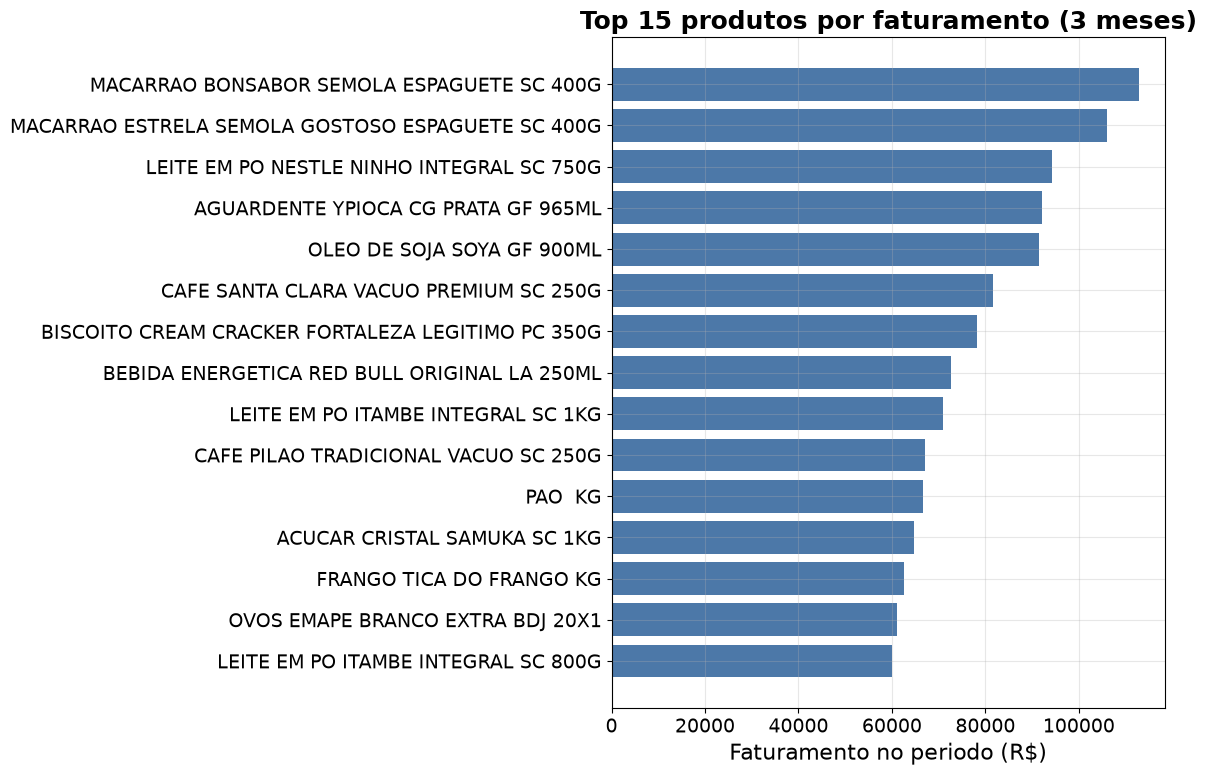

In [6]:
faturamento_produto = (
    df.assign(receita=df["unit_value"] * df["amount"])
    .groupby("description", as_index=False)["receita"].sum()
    .sort_values("receita", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(faturamento_produto["description"][::-1], faturamento_produto["receita"][::-1], color="#4C78A8")
ax.set_xlabel("Faturamento no periodo (R$)")
ax.set_title("Top 15 produtos por faturamento (3 meses)")
plt.tight_layout()
plt.show()


## 4. Foco na BANANA

O produto "BANANA" aparece separado por variedade no cadastro (`BANANA PRATA KG`, `BANANA NANICA KG`, `BANANA MACA KG`). Para representar a demanda do fruto como um todo — que é o que interessa para a gestão de perdas em FLV — somamos as três variedades em uma única série diária de quantidade (kg).

In [7]:
VARIEDADES_BANANA = ["BANANA PRATA KG", "BANANA NANICA KG", "BANANA MACA KG"]

banana = df[df["description"].isin(VARIEDADES_BANANA)]
print(banana.groupby("description")["amount"].agg(dias="count", total_kg="sum", media_kg="mean"))

serie_banana = banana.groupby("date")["amount"].sum().sort_index()
serie_banana.name = "banana_kg"
print(f"\nDias cobertos pela serie de banana: {len(serie_banana)} de {dias_com_venda}")


                  dias  total_kg  media_kg
description                               
BANANA MACA KG     874    849.96      0.97
BANANA NANICA KG  1527  1,506.53      0.99
BANANA PRATA KG   9482 10,691.84      1.13

Dias cobertos pela serie de banana: 90 de 90


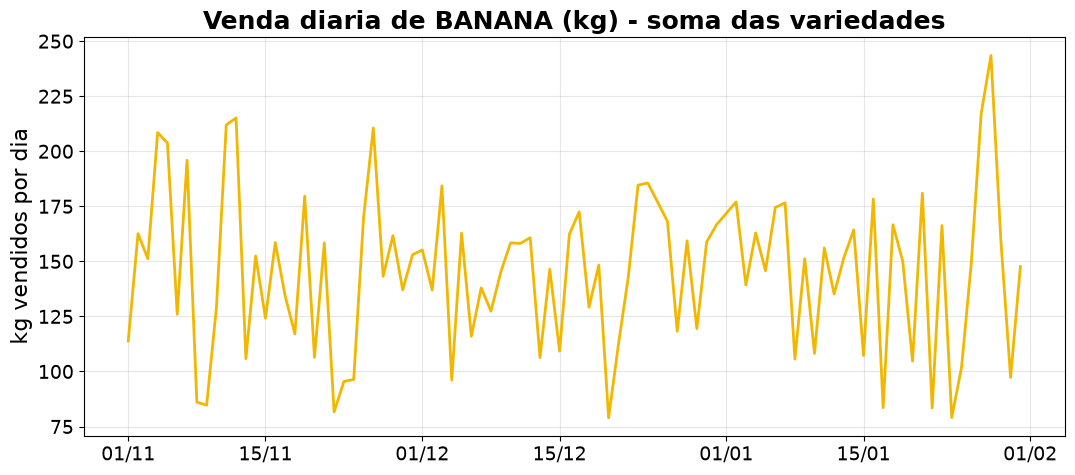

In [8]:
fig, ax = plt.subplots()
ax.plot(serie_banana.index, serie_banana.values, color="#F2B701", linewidth=2)
ax.set_title("Venda diaria de BANANA (kg) - soma das variedades")
ax.set_ylabel("kg vendidos por dia")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
plt.tight_layout()
plt.show()


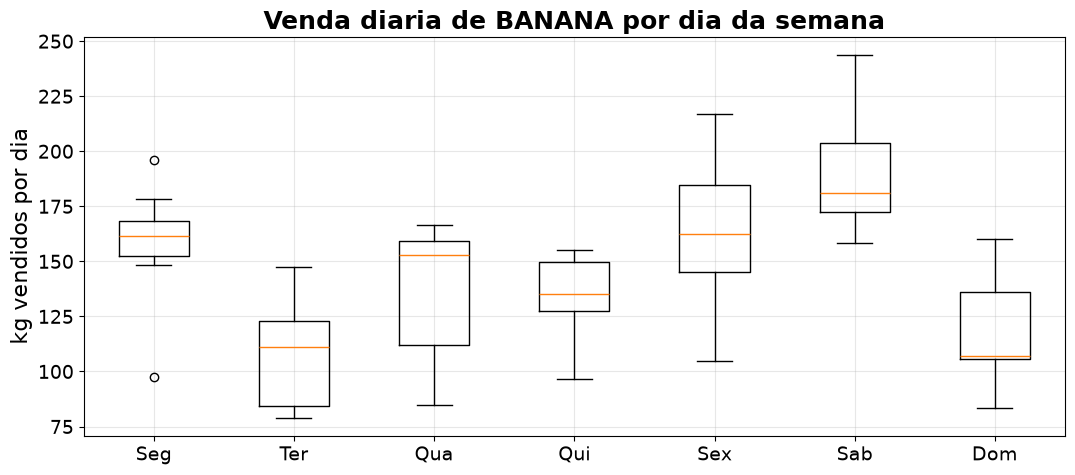

In [9]:
banana_semana = serie_banana.to_frame().copy()
banana_semana["dia_semana"] = banana_semana.index.day_name()
ordem_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
nomes_pt = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sab", "Dom"]

dados_boxplot = [banana_semana.loc[banana_semana["dia_semana"] == d, "banana_kg"] for d in ordem_dias]

fig, ax = plt.subplots()
ax.boxplot(dados_boxplot, tick_labels=nomes_pt)
ax.set_title("Venda diaria de BANANA por dia da semana")
ax.set_ylabel("kg vendidos por dia")
plt.tight_layout()
plt.show()


In [10]:
resumo_semana = banana_semana.groupby("dia_semana")["banana_kg"].agg(["mean", "median", "std", "min", "max", "count"])
resumo_semana = resumo_semana.reindex(ordem_dias)
resumo_semana.index = nomes_pt
print("Estatisticas de venda de BANANA por dia da semana (kg):")
resumo_semana.round(2)


Estatisticas de venda de BANANA por dia da semana (kg):


,mean,median,std,min,max,count
Seg,159.89,161.68,22.79,97.32,195.89,13
Ter,108.57,111.00,23.72,79.00,147.66,14
Qua,138.29,153.00,29.09,84.71,166.63,13
Qui,134.31,135.16,17.74,96.36,155.17,13
Sex,164.84,162.36,34.94,104.66,217.09,13
Sab,187.84,180.99,24.13,158.41,243.52,13
Dom,120.10,107.24,25.27,83.39,160.06,11


A série mostra sazonalidade semanal clara (picos aos finais de semana), típica de FLV — vale a pena o modelo capturar esse padrão.

## 5. Correlação entre séries temporais

Construímos uma tabela larga (dias x produtos) com a quantidade vendida por dia, restrita aos produtos "frequentes" definidos na seção 3, e calculamos a correlação de Pearson de cada produto com a série da BANANA.

In [11]:
pivot = (
    vendas_diarias[vendas_diarias["product_id"].isin(produtos_frequentes)]
    .pivot_table(index="date", columns="description", values="amount", aggfunc="sum")
    .fillna(0.0)
)

pivot["BANANA (total)"] = serie_banana.reindex(pivot.index).fillna(0.0)

correlacoes = (
    pivot.corr()["BANANA (total)"]
    .drop(index=["BANANA (total)"] + VARIEDADES_BANANA, errors="ignore")
    .sort_values(ascending=False)
)

print("Top 15 produtos mais correlacionados (mesmo dia) com a BANANA:")
correlacoes.head(15)


Top 15 produtos mais correlacionados (mesmo dia) com a BANANA:


description
CHEIRO VERDE UN                                     0.58
LA DE ACO BOMBRIL ECO SC 60G 8X1                    0.57
MACA NACIONAL KG                                    0.55
CALDO EM TABLET MAGGI GALINHA CX 114G 12X1          0.55
COLORIFICO EM PO KIMIMO SC 100G                     0.55
PAO RABELO HAMBURGUER PC 400G                       0.54
COLORIFICO EM PO DONA CLARA SC 100G                 0.53
FARINHA DE MANDIOCA GOSTOZZO AMARELA SC 1KG         0.53
PAPEL HIGIENICO FLORAL PERFUMADO PC 30MT 4X1        0.50
LA DE ACO ASSOLAN SC 45G 8X1                        0.49
ACAFRAO NATUVIDA SC 50G                             0.49
BEBIDA LACTEA ISIS POL SALADA DE FRUTAS SC 900G     0.49
PAO RABELO LEITE PC 350G                            0.48
CREME DENTAL COLGATE T ACAO MENTA ORIGINAL CX 90G   0.48
FARINHA DE TRIGO DONA BENTA COM FERMENTO SC 1KG     0.47
Name: BANANA (total), dtype: float64

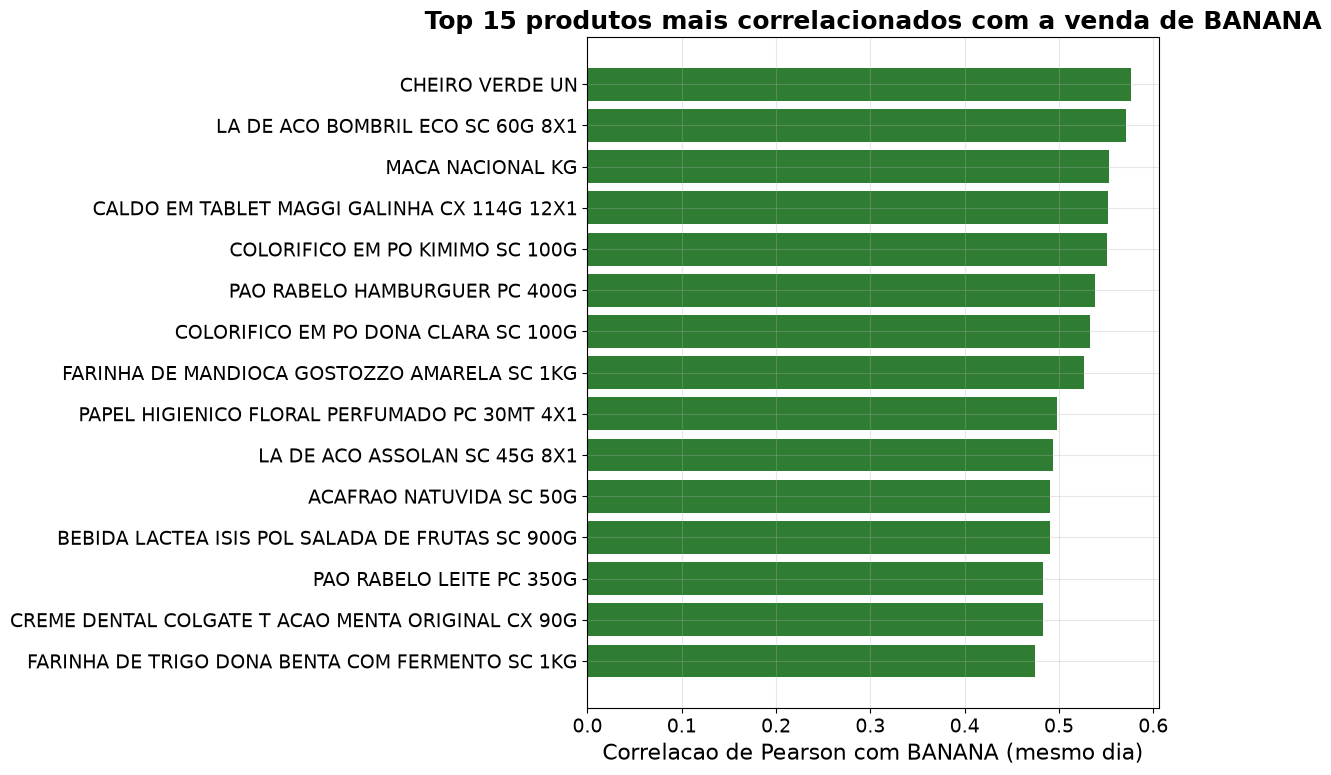

In [12]:
top15 = correlacoes.head(15)

fig, ax = plt.subplots(figsize=(12, 8))
cores = ["#2E7D32" if v >= 0 else "#C62828" for v in top15.values]
ax.barh(top15.index[::-1], top15.values[::-1], color=cores[::-1])
ax.set_xlabel("Correlacao de Pearson com BANANA (mesmo dia)")
ax.set_title("Top 15 produtos mais correlacionados com a venda de BANANA")
plt.tight_layout()
plt.show()


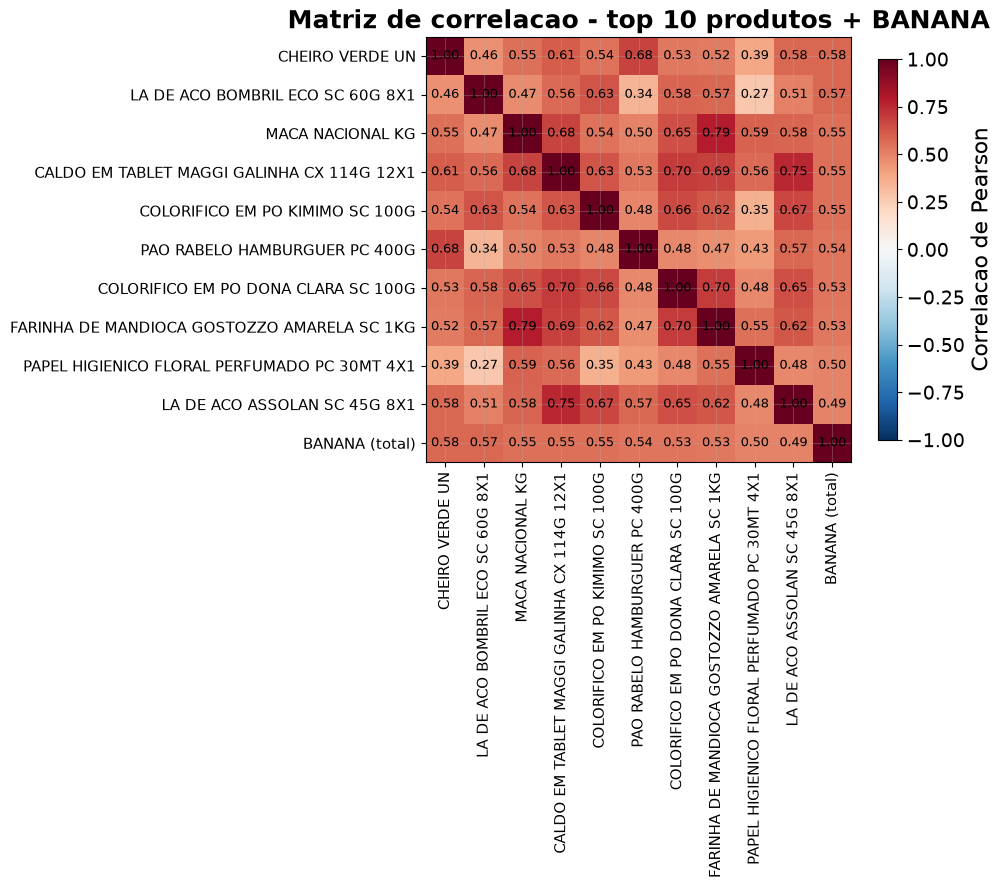

In [13]:
top10_nomes = list(top15.head(10).index) + ["BANANA (total)"]
matriz_top10 = pivot[top10_nomes].corr()

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(matriz_top10.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(top10_nomes)))
ax.set_yticks(range(len(top10_nomes)))
ax.set_xticklabels(top10_nomes, rotation=90, fontsize=11)
ax.set_yticklabels(top10_nomes, fontsize=11)
for i in range(len(top10_nomes)):
    for j in range(len(top10_nomes)):
        ax.text(j, i, f"{matriz_top10.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, shrink=0.8, label="Correlacao de Pearson")
ax.set_title("Matriz de correlacao - top 10 produtos + BANANA")
plt.tight_layout()
plt.show()


### Correlação com defasagem (lag)

Além da correlação no mesmo dia, verificamos se a venda da BANANA se correlaciona melhor com a venda de outro produto **alguns dias antes ou depois** (ex.: compras de itens de salada costumam acontecer no mesmo dia, mas pode haver padrões de antecipação/atraso). Testamos lags de -3 a +3 dias para os 5 produtos mais correlacionados no mesmo dia.

In [14]:
candidatos = list(top15.head(5).index)
lags = range(-3, 4)

resultado_lag = pd.DataFrame(index=lags, columns=candidatos, dtype=float)
for produto in candidatos:
    serie_produto = pivot[produto]
    for lag in lags:
        resultado_lag.loc[lag, produto] = serie_banana.reindex(pivot.index).corr(serie_produto.shift(lag))

print("Correlacao BANANA(t) vs produto(t - lag). lag negativo = produto adianta a banana.")
resultado_lag


Correlacao BANANA(t) vs produto(t - lag). lag negativo = produto adianta a banana.


,CHEIRO VERDE UN,LA DE ACO BOMBRIL ECO SC 60G 8X1,MACA NACIONAL KG,CALDO EM TABLET MAGGI GALINHA CX 114G 12X1,COLORIFICO EM PO KIMIMO SC 100G
-3,-0.19,-0.11,-0.44,-0.33,-0.19
-2,-0.09,-0.02,-0.12,-0.21,-0.15
-1,0.04,0.17,0.19,-0.00,0.14
0,0.58,0.57,0.55,0.55,0.55
1,0.01,0.07,0.14,0.20,0.11
2,0.14,0.07,-0.15,0.05,0.03
3,-0.22,-0.16,-0.10,-0.22,-0.15


**Observação importante:** para quase todos os candidatos, a correlação é forte em lag 0 e cai bruscamente para os demais lags (positivos ou negativos). Esse padrão é típico de um **efeito de calendário compartilhado**: praticamente todo produto de compra frequente vende mais aos finais de semana, então produtos completamente sem relação entre si (ex.: papel higiênico, creme dental) aparecem "correlacionados" com a BANANA só porque ambos sobem no sábado/domingo. Isso é uma correlação espúria para fins de modelagem — o modelo de BANANA já vai aprender esse efeito de dia da semana sozinho (feature `dia_semana`), então não adianta escolher o parceiro apenas pela correlação bruta.

Para achar um parceiro que realmente agregue informação nova, recalculamos a correlação **depois de remover a média de cada dia da semana** de cada série (correlação "des-sazonalizada" / sobre os resíduos).

In [15]:
dia_semana_pivot = pivot.index.dayofweek
medias_por_dia_semana = pivot.groupby(dia_semana_pivot).transform("mean")
pivot_residual = pivot - medias_por_dia_semana

correlacoes_residuais = (
    pivot_residual.corr()["BANANA (total)"]
    .drop(index=["BANANA (total)"] + VARIEDADES_BANANA, errors="ignore")
    .sort_values(ascending=False)
)

print("Top 15 produtos mais correlacionados com a BANANA apos remover o efeito do dia da semana:")
correlacoes_residuais.head(15)


Top 15 produtos mais correlacionados com a BANANA apos remover o efeito do dia da semana:


description
LA DE ACO BOMBRIL ECO SC 60G 8X1                    0.49
FEIJAO CORDA DONA DE SC 1KG                         0.43
ABOBORA CABOCLA KG                                  0.42
BISCOITO CREAM CRACKER MARILAN ESPECIAL PC 350G     0.39
CHEIRO VERDE UN                                     0.38
CREME DENTAL COLGATE T ACAO MENTA ORIGINAL CX 90G   0.38
COLORIFICO EM PO DONA CLARA SC 100G                 0.37
BOLACHA RABELO POP PC 300G                          0.37
BEBIDA LACTEA ISIS POL SALADA DE FRUTAS SC 900G     0.36
CREME DE AVELA NUTELLA COM CACAU PT 140G            0.36
PAPEL HIGIENICO FLORAL PERFUMADO PC 30MT 4X1        0.36
BEBIDA LACTEA ISIS POL MORANGO SC 900G              0.36
ARROZ BRANCO TIO JOAO SC 1KG                        0.35
FARINHA DE TRIGO DONA BENTA COM FERMENTO SC 1KG     0.35
COLORIFICO EM PO KIMIMO SC 100G                     0.35
Name: BANANA (total), dtype: float64

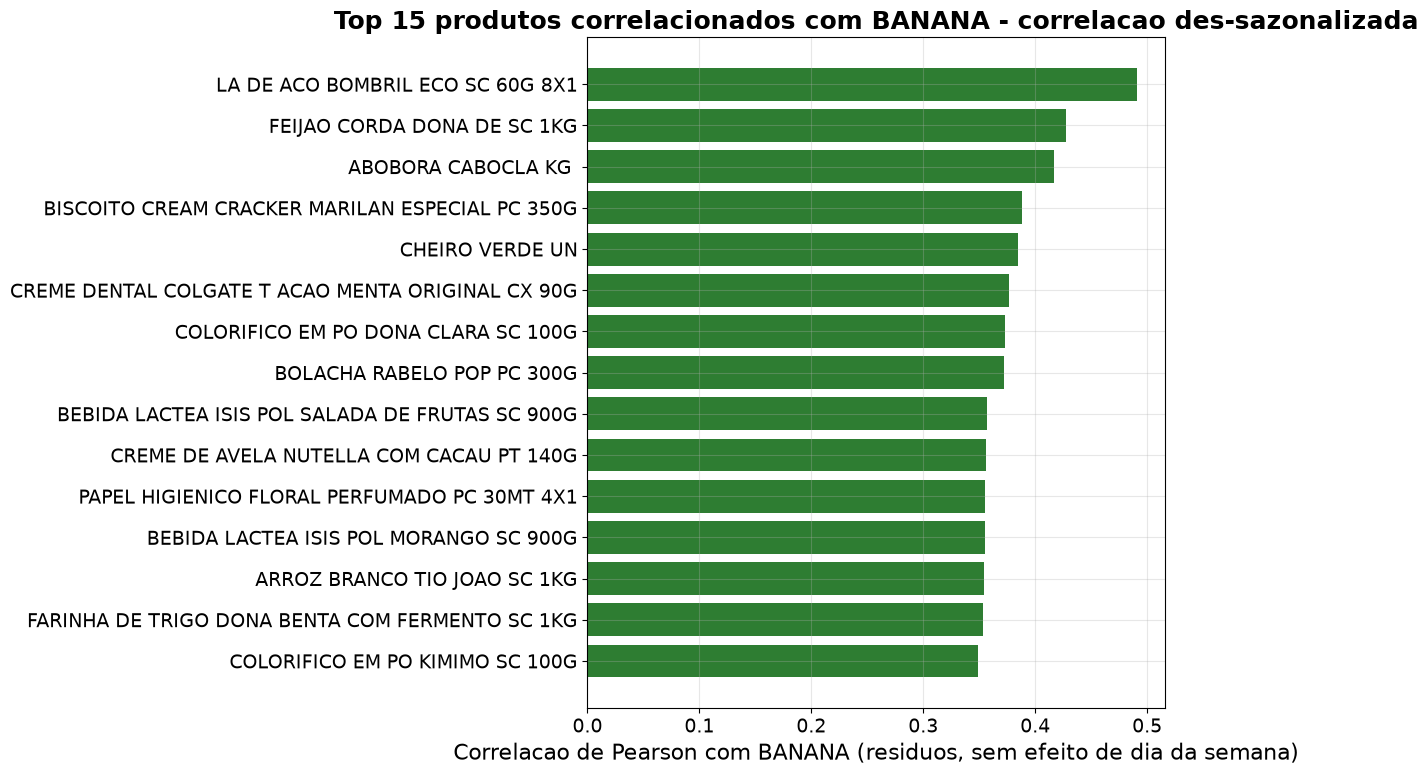

In [16]:
top15_residual = correlacoes_residuais.head(15)

fig, ax = plt.subplots(figsize=(12, 8))
cores = ["#2E7D32" if v >= 0 else "#C62828" for v in top15_residual.values]
ax.barh(top15_residual.index[::-1], top15_residual.values[::-1], color=cores[::-1])
ax.set_xlabel("Correlacao de Pearson com BANANA (residuos, sem efeito de dia da semana)")
ax.set_title("Top 15 produtos correlacionados com BANANA - correlacao des-sazonalizada")
plt.tight_layout()
plt.show()


**Outro cuidado necessário:** entre os 482 produtos frequentes, testamos 482 correlações ao mesmo tempo. Mesmo depois de remover o efeito de dia da semana, é esperado que alguns produtos sem nenhuma relação real com a BANANA (ex.: "lã de aço", "papel higiênico") apareçam com correlação alta só por acaso (problema de comparações múltiplas / falso positivo estatístico) — e de fato é isso que aparece no topo da lista acima.

Para escolher um parceiro que faça sentido de negócio (e não apenas estatístico), restringimos a escolha final aos **produtos de FLV/hortifrúti** — mesmo departamento da BANANA, onde correlações têm uma explicação plausível (ex.: clima, sazonalidade de safra, cesta de compras de hortifrúti).

In [17]:
FLV_HORTIFRUTI = {
    "ABACATE KG", "ABOBORA CABOCLA KG", "ABOBORA JACARE KG", "ABOBORA LEITE KG", "ABOBRINHA VERDE KG",
    "ALHO A GRANEL KG", "BATATA DOCE KG", "BATATA INGLESA KG", "BETERRABA KG", "BROCOLIS KG",
    "CEBOLA BRANCA KG", "CEBOLA ROXA KG", "CENOURA KG", "CHEIRO VERDE UN", "CHUCHU KG", "COUVE FLOR KG",
    "GOIABA KG", "KIWI IMPORTADO KG", "LARANJA KG", "LIMAO TAITI KG", "MACA ARGENTINA KG", "MACA NACIONAL KG",
    "MACAXEIRA KG", "MAMAO FORMOSA KG", "MANGA COITE KG", "MANGA TOMMY KG", "MARACUJA KG",
    "MELANCIA BABY KG", "MELANCIA KG", "MELAO ESPANHOL AMARELO KG", "MELAO JAPONES KG", "MELAO SAPIER KG",
    "PEPINO KG", "PERA DANJOU KG", "PIMENTA DE CHEIRO KG", "PIMENTAO VERDE KG", "REPOLHO ROXO KG",
    "REPOLHO VERDE KG", "TANGERINA IMPORTADA KG", "TANGERINA MURCOTE KG", "TOMATE KG",
}

correlacoes_flv = correlacoes_residuais[
    [c for c in correlacoes_residuais.index if c.strip().upper() in FLV_HORTIFRUTI]
].sort_values(ascending=False)

print(f"Produtos de FLV/hortifruti disponiveis para comparacao: {len(correlacoes_flv)}")
print("\nCorrelacao (des-sazonalizada) com BANANA, apenas produtos de FLV/hortifruti:")
correlacoes_flv


Produtos de FLV/hortifruti disponiveis para comparacao: 41

Correlacao (des-sazonalizada) com BANANA, apenas produtos de FLV/hortifruti:


description
ABOBORA CABOCLA KG            0.42
CHEIRO VERDE UN               0.38
MACA NACIONAL KG              0.35
PIMENTA DE CHEIRO KG          0.34
LARANJA KG                    0.34
BROCOLIS KG                   0.33
PERA DANJOU KG                0.33
CEBOLA BRANCA KG              0.28
MAMAO FORMOSA KG              0.27
GOIABA KG                     0.25
ABACATE KG                    0.24
PEPINO KG                     0.24
TANGERINA MURCOTE KG          0.23
ALHO A GRANEL KG              0.23
TOMATE KG                     0.22
MELANCIA KG                   0.22
PIMENTAO VERDE KG             0.19
TANGERINA IMPORTADA KG        0.15
BATATA DOCE KG                0.15
MANGA TOMMY KG                0.14
ABOBRINHA VERDE KG            0.14
MELAO ESPANHOL AMARELO KG     0.14
CENOURA KG                    0.13
KIWI IMPORTADO KG             0.11
REPOLHO VERDE KG              0.11
MARACUJA KG                   0.10
ABOBORA JACARE KG             0.09
BETERRABA KG                  0.09
CEBOLA R

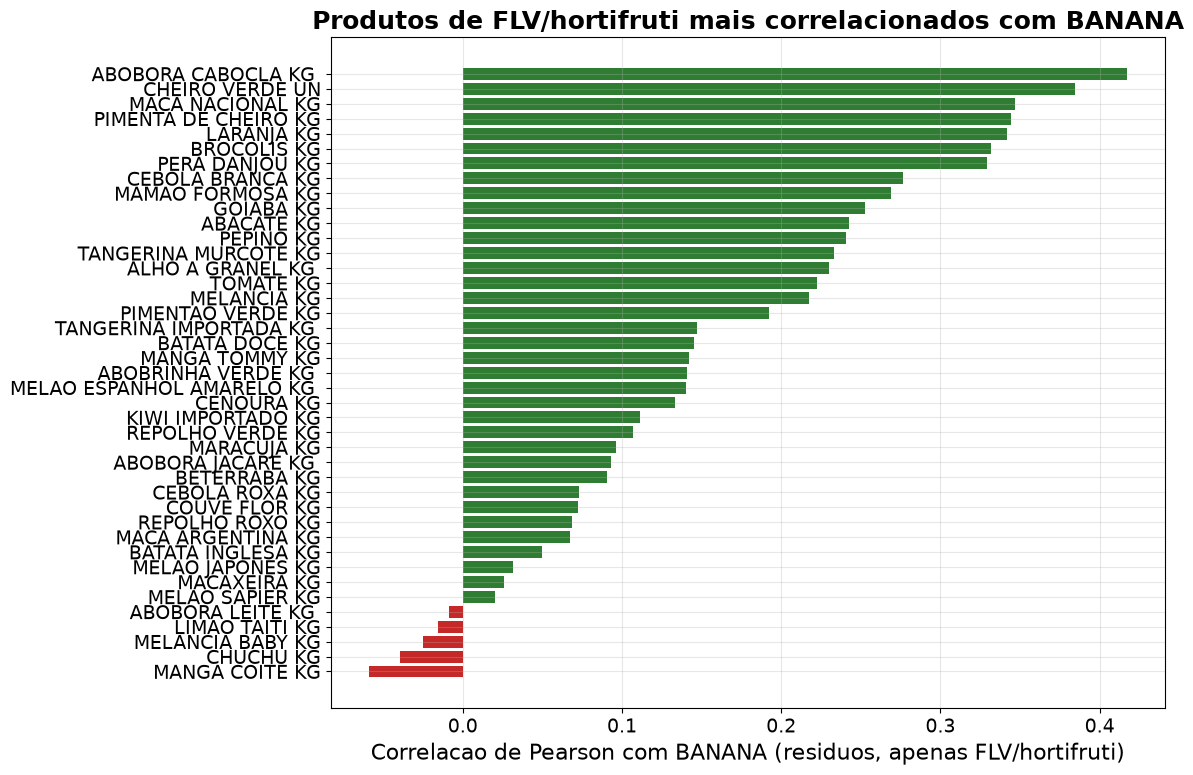

In [18]:
fig, ax = plt.subplots(figsize=(12, 8))
cores = ["#2E7D32" if v >= 0 else "#C62828" for v in correlacoes_flv.values]
ax.barh(correlacoes_flv.index[::-1], correlacoes_flv.values[::-1], color=cores[::-1])
ax.set_xlabel("Correlacao de Pearson com BANANA (residuos, apenas FLV/hortifruti)")
ax.set_title("Produtos de FLV/hortifruti mais correlacionados com BANANA")
plt.tight_layout()
plt.show()


In [19]:
produto_escolhido = correlacoes_flv.index[0]
banana_residual = pivot_residual["BANANA (total)"]

lags_seguros = range(1, 4)
correlacao_lag_residual = pd.Series({
    lag: banana_residual.corr(pivot_residual[produto_escolhido].shift(lag)) for lag in lags_seguros
})
melhor_lag = int(correlacao_lag_residual.abs().idxmax())

print(f"Produto escolhido para combinar com a BANANA: '{produto_escolhido}'")
print(f"Correlacao (des-sazonalizada, mesmo dia): {correlacoes_flv.iloc[0]:.3f}")
print(f"Melhor lag entre 1 e 3 dias (usando so informacao passada): {melhor_lag} dia(s) | correlacao: {correlacao_lag_residual[melhor_lag]:.3f}")


Produto escolhido para combinar com a BANANA: 'ABOBORA CABOCLA KG '
Correlacao (des-sazonalizada, mesmo dia): 0.417
Melhor lag entre 1 e 3 dias (usando so informacao passada): 1 dia(s) | correlacao: 0.342


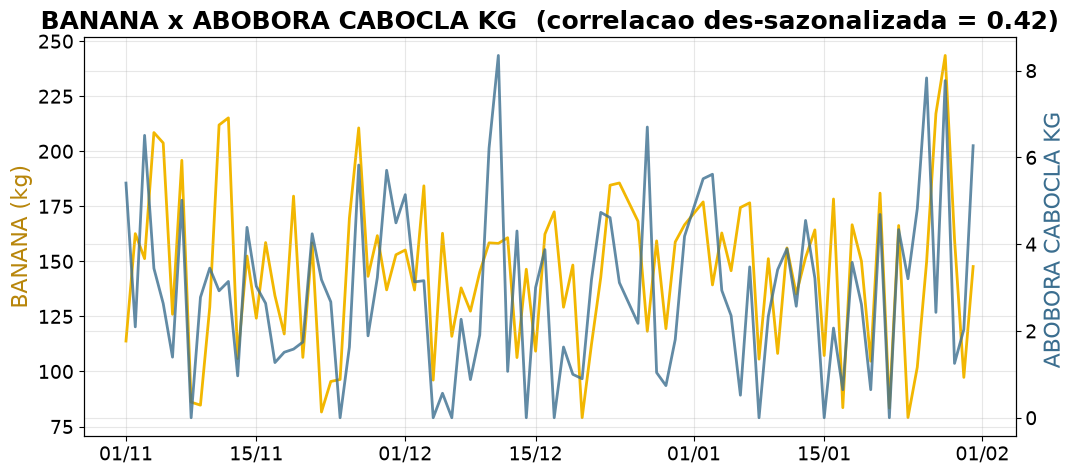

In [20]:
fig, ax1 = plt.subplots()
ax1.plot(serie_banana.index, serie_banana.values, color="#F2B701", label="BANANA (kg)", linewidth=2)
ax1.set_ylabel("BANANA (kg)", color="#B8860B")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))

ax2 = ax1.twinx()
ax2.plot(pivot.index, pivot[produto_escolhido].values, color="#3B6E8F", alpha=0.8, label=produto_escolhido, linewidth=2)
ax2.set_ylabel(produto_escolhido, color="#3B6E8F")

ax1.set_title(f"BANANA x {produto_escolhido} (correlacao des-sazonalizada = {correlacoes_flv.iloc[0]:.2f})")
fig.tight_layout()
plt.show()


## 6. Preparação para modelagem preditiva

Construímos variáveis (features) baseadas em defasagens (lags) e médias móveis da própria série de BANANA, além de variáveis de calendário (dia da semana / fim de semana). Reservamos os **últimos 14 dias** como conjunto de teste (fora da amostra de treino).

In [21]:
def montar_features(serie, nome, lags=(1, 2, 7), janela_media_movel=7):
    base = serie.to_frame(nome)
    for lag in lags:
        base[f"{nome}_lag{lag}"] = base[nome].shift(lag)
    base[f"{nome}_media_movel{janela_media_movel}"] = base[nome].shift(1).rolling(janela_media_movel).mean()
    return base.drop(columns=[nome])

dados = montar_features(serie_banana, "banana")
dados["dia_semana"] = dados.index.dayofweek
dados["fim_de_semana"] = (dados["dia_semana"] >= 5).astype(int)
dados["alvo"] = serie_banana.reindex(dados.index)
dados = dados.dropna()

DIAS_TESTE = 14
treino = dados.iloc[:-DIAS_TESTE]
teste = dados.iloc[-DIAS_TESTE:]

colunas_features = [c for c in dados.columns if c != "alvo"]
X_treino, y_treino = treino[colunas_features], treino["alvo"]
X_teste, y_teste = teste[colunas_features], teste["alvo"]

print(f"Treino: {len(treino)} dias ({treino.index.min().date()} a {treino.index.max().date()})")
print(f"Teste:  {len(teste)} dias ({teste.index.min().date()} a {teste.index.max().date()})")


Treino: 69 dias (2022-11-08 a 2023-01-17)
Teste:  14 dias (2023-01-18 a 2023-01-31)


## 7. Métrica de avaliação e modelos baseline

Usamos MAE, RMSE e MAPE para comparar os modelos. Como baseline simples, testamos: repetir o último valor observado (naive), repetir o valor de 7 dias atrás (naive sazonal) e a média móvel de 7 dias.

In [22]:
resultados = []

def avaliar(nome, y_real, y_previsto):
    mae = mean_absolute_error(y_real, y_previsto)
    rmse = root_mean_squared_error(y_real, y_previsto)
    mape = float(np.mean(np.abs((y_real - y_previsto) / y_real)) * 100)
    resultados.append({"modelo": nome, "MAE": mae, "RMSE": rmse, "MAPE (%)": mape})
    return y_previsto

pred_naive = avaliar("Naive (ultimo valor)", y_teste, X_teste["banana_lag1"].values)
pred_naive_sazonal = avaliar("Naive sazonal (lag 7)", y_teste, X_teste["banana_lag7"].values)
pred_media_movel = avaliar("Media movel (7 dias)", y_teste, X_teste["banana_media_movel7"].values)

pd.DataFrame(resultados)


,modelo,MAE,RMSE,MAPE (%)
0,Naive (ultimo valor),60.72,65.76,47.90
1,Naive sazonal (lag 7),41.71,53.21,29.89
2,Media movel (7 dias),42.15,51.01,31.70


## 8. Modelos de machine learning (univariados)

Agora usamos as features de lag/média móvel/calendário em três modelos de regressão: Regressão Linear, Random Forest e Gradient Boosting.

In [23]:
modelos_ml = {
    "Regressao Linear": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=2, learning_rate=0.05, random_state=42),
}

previsoes_uni = {}
for nome, modelo in modelos_ml.items():
    modelo.fit(X_treino, y_treino)
    previsao = modelo.predict(X_teste)
    previsoes_uni[nome] = previsao
    avaliar(nome + " (univariado)", y_teste, previsao)

pd.DataFrame(resultados)


,modelo,MAE,RMSE,MAPE (%)
0,Naive (ultimo valor),60.72,65.76,47.90
1,Naive sazonal (lag 7),41.71,53.21,29.89
2,Media movel (7 dias),42.15,51.01,31.70
3,Regressao Linear (univariado),37.43,43.51,29.30
4,Random Forest (univariado),35.02,41.06,25.58
5,Gradient Boosting (univariado),35.10,42.16,26.17


## 9. Comparação dos modelos univariados

,modelo,MAE,RMSE,MAPE (%)
4,Random Forest (univariado),35.02,41.06,25.58
5,Gradient Boosting (univariado),35.10,42.16,26.17
3,Regressao Linear (univariado),37.43,43.51,29.30
2,Media movel (7 dias),42.15,51.01,31.70
1,Naive sazonal (lag 7),41.71,53.21,29.89
0,Naive (ultimo valor),60.72,65.76,47.90


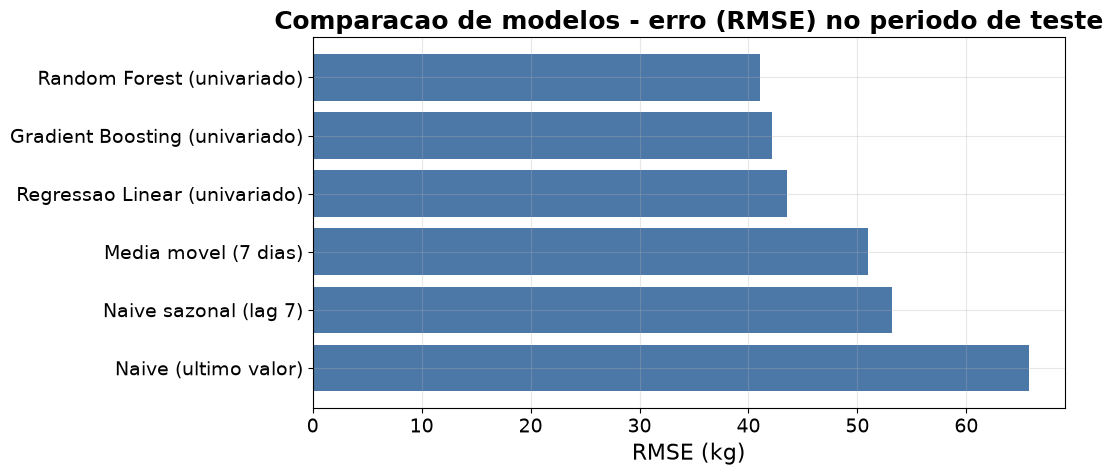

Melhor modelo (univariado): Random Forest (univariado)


In [24]:
tabela_resultados = pd.DataFrame(resultados).sort_values("RMSE")
display(tabela_resultados)

fig, ax = plt.subplots()
ax.barh(tabela_resultados["modelo"][::-1], tabela_resultados["RMSE"][::-1], color="#4C78A8")
ax.set_xlabel("RMSE (kg)")
ax.set_title("Comparacao de modelos - erro (RMSE) no periodo de teste")
plt.tight_layout()
plt.show()

melhor_modelo_nome = tabela_resultados.iloc[0]["modelo"]
print(f"Melhor modelo (univariado): {melhor_modelo_nome}")


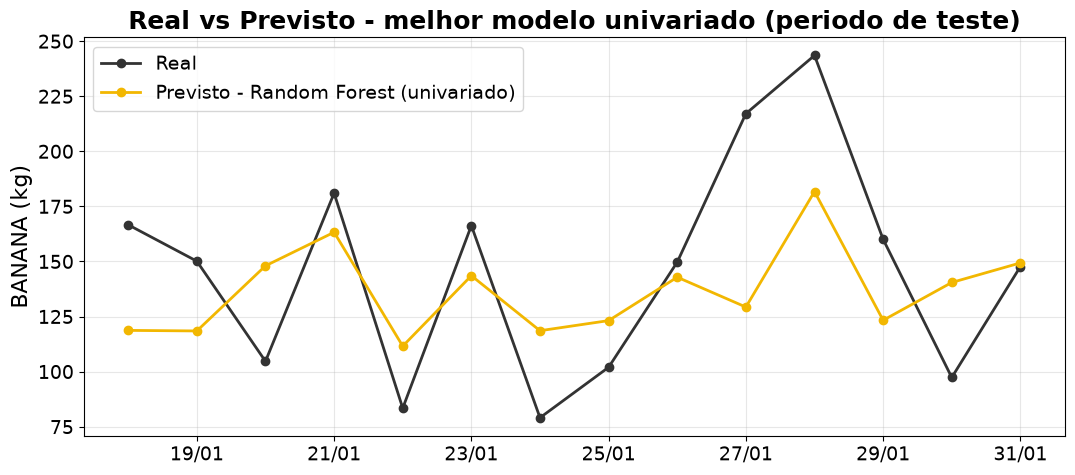

In [25]:
melhor_previsao_uni = previsoes_uni.get(
    melhor_modelo_nome.replace(" (univariado)", ""), pred_media_movel
)

fig, ax = plt.subplots()
ax.plot(y_teste.index, y_teste.values, marker="o", label="Real", color="#333333", linewidth=2)
ax.plot(y_teste.index, melhor_previsao_uni, marker="o", label=f"Previsto - {melhor_modelo_nome}", color="#F2B701", linewidth=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax.set_ylabel("BANANA (kg)")
ax.set_title("Real vs Previsto - melhor modelo univariado (periodo de teste)")
ax.legend()
plt.tight_layout()
plt.show()


## 10. Combinando BANANA com o produto correlacionado

Repetimos a modelagem de machine learning, agora **adicionando features do produto correlacionado** encontrado na seção 5: seu valor defasado no melhor lag identificado, além de lag 1 e média móvel de 7 dias. A ideia é testar a hipótese do professor: a série combinada deve superar o modelo que usa apenas o histórico da própria BANANA.

In [26]:
serie_parceiro = pivot[produto_escolhido].reindex(serie_banana.index)

dados_combo = montar_features(serie_banana, "banana")
dados_combo["dia_semana"] = dados_combo.index.dayofweek
dados_combo["fim_de_semana"] = (dados_combo["dia_semana"] >= 5).astype(int)

for lag in sorted({1, melhor_lag}):
    dados_combo[f"parceiro_lag{lag}"] = serie_parceiro.shift(lag)
dados_combo["parceiro_media_movel7"] = serie_parceiro.shift(1).rolling(7).mean()

dados_combo["alvo"] = serie_banana.reindex(dados_combo.index)
dados_combo = dados_combo.dropna()

treino_combo = dados_combo.loc[dados_combo.index.isin(treino.index)]
teste_combo = dados_combo.loc[dados_combo.index.isin(teste.index)]

colunas_combo = [c for c in dados_combo.columns if c != "alvo"]
X_treino_combo, y_treino_combo = treino_combo[colunas_combo], treino_combo["alvo"]
X_teste_combo, y_teste_combo = teste_combo[colunas_combo], teste_combo["alvo"]

print(f"Features do modelo combinado: {colunas_combo}")
print(f"Treino: {len(treino_combo)} dias | Teste: {len(teste_combo)} dias")


Features do modelo combinado: ['banana_lag1', 'banana_lag2', 'banana_lag7', 'banana_media_movel7', 'dia_semana', 'fim_de_semana', 'parceiro_lag1', 'parceiro_media_movel7']
Treino: 69 dias | Teste: 14 dias


In [27]:
nome_base = melhor_modelo_nome.replace(" (univariado)", "")
if nome_base not in modelos_ml:
    nome_base = "Gradient Boosting"

ModeloClasse = type(modelos_ml[nome_base])
modelo_combo = ModeloClasse(**modelos_ml[nome_base].get_params())
modelo_combo.fit(X_treino_combo, y_treino_combo)
pred_combo = modelo_combo.predict(X_teste_combo)

avaliar(f"{nome_base} + produto correlacionado", y_teste_combo, pred_combo)

pd.DataFrame(resultados).sort_values("RMSE")


,modelo,MAE,RMSE,MAPE (%)
6,Random Forest + produto correlacionado,35.03,40.50,25.81
4,Random Forest (univariado),35.02,41.06,25.58
5,Gradient Boosting (univariado),35.10,42.16,26.17
3,Regressao Linear (univariado),37.43,43.51,29.30
2,Media movel (7 dias),42.15,51.01,31.70
1,Naive sazonal (lag 7),41.71,53.21,29.89
0,Naive (ultimo valor),60.72,65.76,47.90


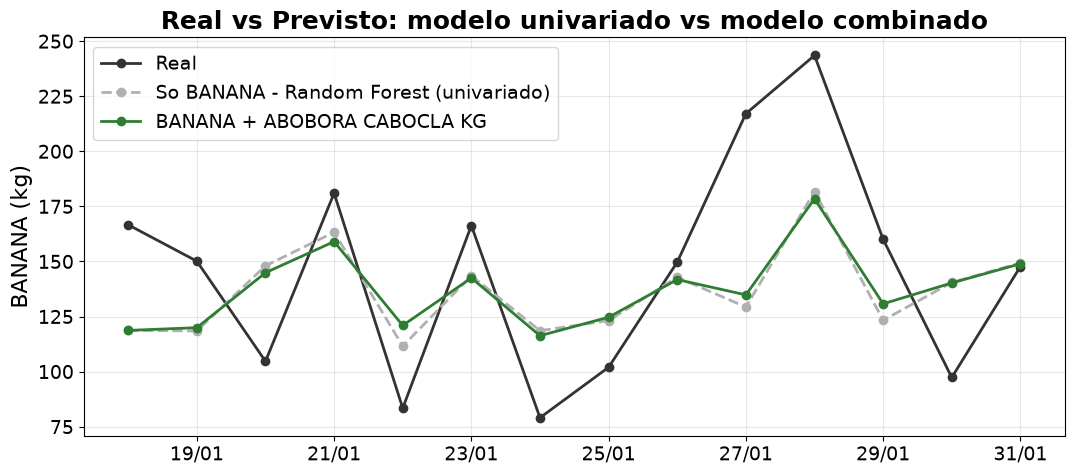

RMSE apenas BANANA: 41.06 kg
RMSE BANANA + ABOBORA CABOCLA KG : 40.50 kg
Reducao de erro (RMSE): 1.4%


In [28]:
rmse_uni = tabela_resultados.set_index("modelo").loc[melhor_modelo_nome, "RMSE"]
rmse_combo = pd.DataFrame(resultados).set_index("modelo").loc[f"{nome_base} + produto correlacionado", "RMSE"]
ganho_pct = (rmse_uni - rmse_combo) / rmse_uni * 100

fig, ax = plt.subplots()
ax.plot(y_teste_combo.index, y_teste_combo.values, marker="o", label="Real", color="#333333", linewidth=2)
ax.plot(y_teste.index, melhor_previsao_uni, marker="o", linestyle="--", label=f"So BANANA - {melhor_modelo_nome}", color="#B0B0B0", linewidth=2)
ax.plot(y_teste_combo.index, pred_combo, marker="o", label=f"BANANA + {produto_escolhido}", color="#2E7D32", linewidth=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax.set_ylabel("BANANA (kg)")
ax.set_title("Real vs Previsto: modelo univariado vs modelo combinado")
ax.legend()
plt.tight_layout()
plt.show()

print(f"RMSE apenas BANANA: {rmse_uni:.2f} kg")
print(f"RMSE BANANA + {produto_escolhido}: {rmse_combo:.2f} kg")
print(f"Reducao de erro (RMSE): {ganho_pct:.1f}%")


In [29]:
dias_combo_vence = int((np.abs(y_teste_combo.values - pred_combo) < np.abs(y_teste.values - melhor_previsao_uni)).sum())
print(f"Dias em que o modelo combinado teve erro menor: {dias_combo_vence} de {len(y_teste_combo)} ({dias_combo_vence/len(y_teste_combo)*100:.1f}%)")


Dias em que o modelo combinado teve erro menor: 7 de 14 (50.0%)


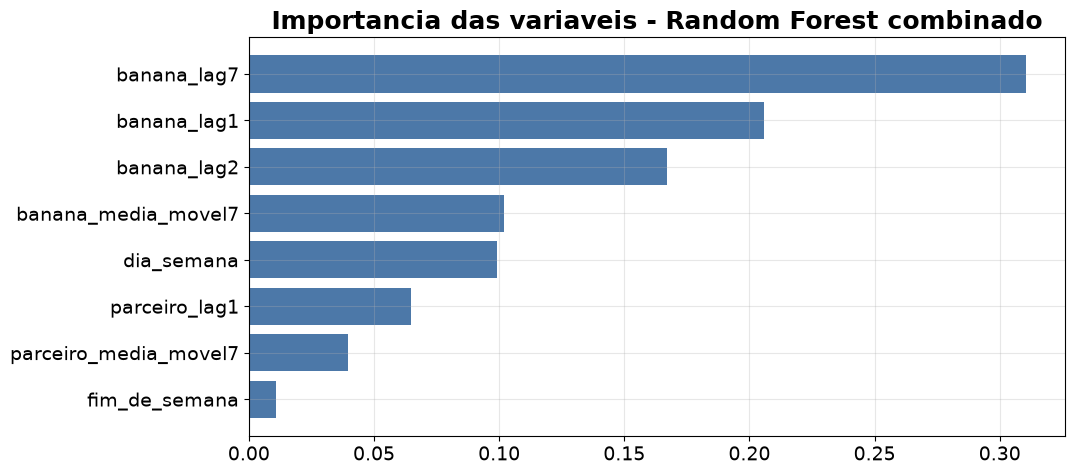

In [30]:
if hasattr(modelo_combo, "feature_importances_"):
    importancias = pd.Series(modelo_combo.feature_importances_, index=colunas_combo).sort_values()
    fig, ax = plt.subplots()
    ax.barh(importancias.index, importancias.values, color="#4C78A8")
    ax.set_title(f"Importancia das variaveis - {nome_base} combinado")
    plt.tight_layout()
    plt.show()
else:
    print("O modelo escolhido nao expoe feature_importances_ (ex.: Regressao Linear). Veja os coeficientes abaixo:")
    print(pd.Series(modelo_combo.coef_, index=colunas_combo).sort_values())


## 11. Complemento: previsão específica por dia da semana

A performance geral dos modelos das seções anteriores é modesta (RMSE em torno de 40 kg, para uma média de ~145 kg/dia). Uma hipótese é que o modelo diário "genérico" não está aproveitando ao máximo o forte padrão semanal da BANANA (Seção 4). Como complemento, testamos aqui uma abordagem mais simples e direta: em vez de prever "o próximo dia" de forma genérica, prevemos **um dia da semana específico** (ex.: "qual será a venda da próxima terça-feira?"), usando apenas o histórico daquele mesmo dia da semana.

Essa abordagem interessa especialmente à operação do supermercado: saber, com mais precisão, o comportamento esperado no dia de **menor venda** (para não comprar demais) e no dia de **maior venda** (para não faltar produto).

In [31]:
# Para cada data de teste, preve usando a media das ultimas `janela` ocorrencias
# do MESMO dia da semana (ex.: para prever uma terca-feira, usa so tercas-feiras anteriores).
def prever_por_dia_semana(serie_treino, indices_teste, janela=4):
    historico = serie_treino.copy()
    previsoes = {}
    for data in indices_teste:
        mesmo_dia_semana = historico[historico.index.dayofweek == data.dayofweek]
        ultimas = mesmo_dia_semana.tail(janela)
        previsoes[data] = ultimas.mean() if len(ultimas) > 0 else historico.mean()
        # a previsao de um dia de teste pode "alimentar" a previsao dos dias de teste seguintes do mesmo dia da semana
        historico = pd.concat([historico, pd.Series([y_teste_combo.get(data, np.nan)], index=[data])]).dropna()
    return pd.Series(previsoes)

serie_treino_completa = serie_banana.loc[treino.index]
pred_dia_semana = prever_por_dia_semana(serie_treino_completa, list(y_teste.index), janela=4)
pred_dia_semana = pred_dia_semana.reindex(y_teste.index)

avaliar("Media movel por dia da semana (complemento)", y_teste, pred_dia_semana.values)
pd.DataFrame(resultados).sort_values("RMSE")


,modelo,MAE,RMSE,MAPE (%)
6,Random Forest + produto correlacionado,35.03,40.50,25.81
4,Random Forest (univariado),35.02,41.06,25.58
5,Gradient Boosting (univariado),35.10,42.16,26.17
3,Regressao Linear (univariado),37.43,43.51,29.30
7,Media movel por dia da semana (complemento),40.24,47.03,31.66
2,Media movel (7 dias),42.15,51.01,31.70
1,Naive sazonal (lag 7),41.71,53.21,29.89
0,Naive (ultimo valor),60.72,65.76,47.90


In [32]:
nomes_pt_map = {0: "Segunda", 1: "Terca", 2: "Quarta", 3: "Quinta", 4: "Sexta", 5: "Sabado", 6: "Domingo"}

comparacao_dia = pd.DataFrame({
    "dia_semana": [nomes_pt_map[d.dayofweek] for d in y_teste.index],
    "real": y_teste.values,
    "previsto_media_dia_semana": pred_dia_semana.values,
    "previsto_random_forest": melhor_previsao_uni,
}, index=y_teste.index)
comparacao_dia["erro_abs_dia_semana"] = (comparacao_dia["real"] - comparacao_dia["previsto_media_dia_semana"]).abs()
comparacao_dia["erro_abs_random_forest"] = (comparacao_dia["real"] - comparacao_dia["previsto_random_forest"]).abs()

print("Previsao para o dia da semana de MENOR venda media (Terca-feira) no periodo de teste:")
display(comparacao_dia[comparacao_dia["dia_semana"] == "Terca"].round(2))

print("\nPrevisao para o dia da semana de MAIOR venda media (Sabado) no periodo de teste:")
display(comparacao_dia[comparacao_dia["dia_semana"] == "Sabado"].round(2))

erro_medio_por_dia = comparacao_dia.groupby("dia_semana")[["erro_abs_dia_semana", "erro_abs_random_forest"]].mean()
erro_medio_por_dia = erro_medio_por_dia.reindex(["Segunda", "Terca", "Quarta", "Quinta", "Sexta", "Sabado", "Domingo"])
print("\nErro absoluto medio por dia da semana (kg) - modelo por dia da semana vs Random Forest:")
erro_medio_por_dia.round(2)


Previsao para o dia da semana de MENOR venda media (Terca-feira) no periodo de teste:


,dia_semana,real,previsto_media_dia_semana,previsto_random_forest,erro_abs_dia_semana,erro_abs_random_forest
date,,,,,,
2023-01-24,Terca,79.05,112.33,118.55,33.28,39.50
2023-01-31,Terca,147.66,102.53,149.33,45.13,1.67



Previsao para o dia da semana de MAIOR venda media (Sabado) no periodo de teste:


,dia_semana,real,previsto_media_dia_semana,previsto_random_forest,erro_abs_dia_semana,erro_abs_random_forest
date,,,,,,
2023-01-21,Sabado,180.99,173.27,163.25,7.72,17.74
2023-01-28,Sabado,243.52,172.12,181.72,71.40,61.80



Erro absoluto medio por dia da semana (kg) - modelo por dia da semana vs Random Forest:


,erro_abs_dia_semana,erro_abs_random_forest
dia_semana,,
Segunda,36.65,32.94
Terca,39.21,20.59
Quarta,39.14,34.56
Quinta,13.21,19.27
Sexta,66.20,65.57
Sabado,39.56,39.77
Domingo,47.68,32.46


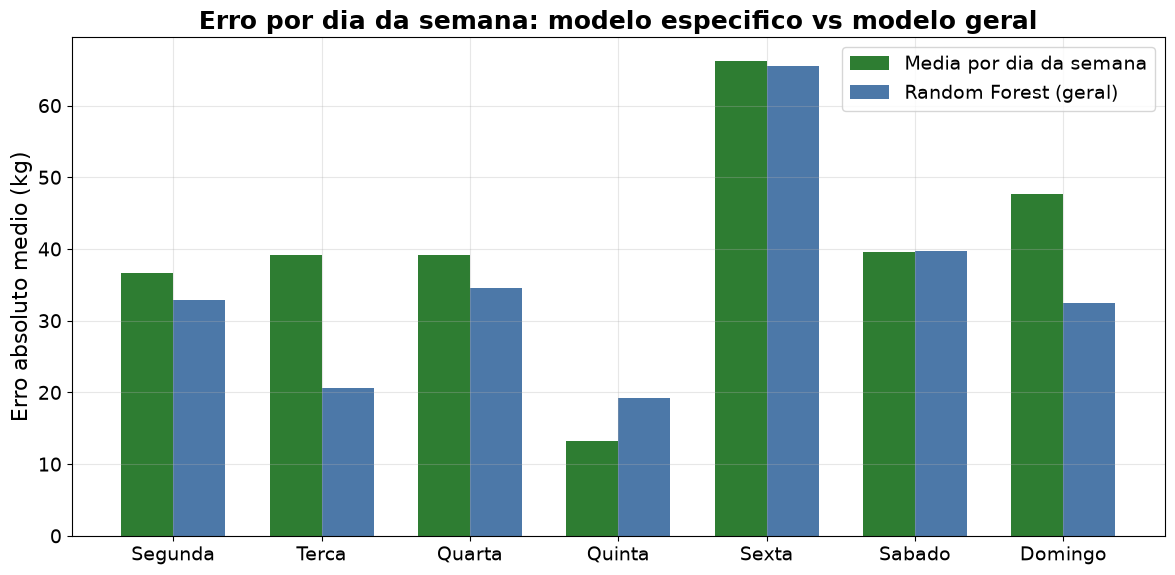

In [33]:
fig, ax = plt.subplots(figsize=(12, 6))
largura = 0.35
posicoes = np.arange(len(erro_medio_por_dia))
ax.bar(posicoes - largura/2, erro_medio_por_dia["erro_abs_dia_semana"], largura, label="Media por dia da semana", color="#2E7D32")
ax.bar(posicoes + largura/2, erro_medio_por_dia["erro_abs_random_forest"], largura, label="Random Forest (geral)", color="#4C78A8")
ax.set_xticks(posicoes)
ax.set_xticklabels(erro_medio_por_dia.index, rotation=0)
ax.set_ylabel("Erro absoluto medio (kg)")
ax.set_title("Erro por dia da semana: modelo especifico vs modelo geral")
ax.legend()
plt.tight_layout()
plt.show()


Essa comparação simples mostra o quanto (ou quão pouco) a previsão melhora quando tratamos cada dia da semana separadamente, em vez de um único modelo genérico para todos os dias — informação direta para a operação da loja decidir compra e reposição de BANANA por dia da semana.